Make ROOT independent of where the Jupyter server is launched:

In [3]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/home/urdatorn/git/gh/aristophanis-cantica


# Prepare the permuted baselines

When running for the first time, set create_perms to True. 

If the all the permuted files are already in the temp_dir, then run with false to just update all stats and plots.

To use pickled distributions of test statistics instead of recalculating for the plots, use from_pickle.

In [17]:
base_cycles = 1000

create_perms = False
from_pickle = False

Define the permutation functions...

In [5]:
from math import gamma as Γ
import hashlib
import random
import re
from typing import Iterator
from tqdm import tqdm

baseline_files = []
for n in [2, 3, 4]:
    tetrameter = ROOT / f"data/compiled/baselines/baseline_aristophanes/tetrameter_{n}.xml"
    trimeter = ROOT / f"data/compiled/baselines/baseline_aristophanes/trimeter_{n}.xml"
    baseline_files.append(tetrameter)
    baseline_files.append(trimeter)

# Make permutated versions of all canticum elements in each of the six files.
# Important points:
# - What's permuted are the l element orderings of each of its strophes.
# - It is key that the permutation is different for all strophes inside the same canticum, so responsion is not conserved, otherwise the permutation test will not work
# - There are n! possible permutations for a strophe with n lines
# - 8! is the smallest factorial > 10 000,
#   so 13-strophic songs would need to be 8-lined at least to enable 10k permutations.
# - But they are 3-lined, hence we can only do 6 permutations.
# - Comic tetrameters are capped out so increasing is only an option for trimeters.

factorial = lambda n: int(Γ(n + 1))
permutations = factorial(3) # max permutations of the 13-strophic baseline odes

temp_dir = ROOT / "data/compiled/baselines/baseline_aristophanes/temp_permutations"

canticum_re = re.compile(r"(<canticum\b[^>]*>)(.*?)(</canticum>)", re.S)
strophe_re = re.compile(r"(<strophe\b[^>]*>)(.*?)(</strophe>)", re.S)


def parse_source_key_from_l_line(l_line: str) -> tuple[str, int] | None:
    """Return (source_canticum, source_internal_line_nr) parsed from @n, else None."""
    m = re.search(r'\bn="([^"]+)"', l_line)
    if not m:
        return None
    n_val = m.group(1)
    parts = n_val.split("_")
    if len(parts) < 2:
        return None
    try:
        source_canticum = parts[0]
        strophe_internal = parts[1]  # e.g. 1-3
        internal_line_nr = int(strophe_internal.split("-")[1])
        return (source_canticum, internal_line_nr)
    except Exception:
        return None


def extract_strophe_structures(canticum_body: str):
    """Parse strophe bodies and keep mutable split-lines representation for replacement."""
    structures = []
    for sm in strophe_re.finditer(canticum_body):
        strophe_open, strophe_body, strophe_close = sm.groups()
        lines = strophe_body.splitlines(keepends=True)
        l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]
        structures.append(
            {
                "open": strophe_open,
                "close": strophe_close,
                "lines": lines,
                "l_indices": l_indices,
            }
        )
    return structures


def tetrameter_constraint_holds(text: str) -> bool:
    """Check: within each output canticum, same line position across strophes cannot reuse same source key."""
    for c_match in canticum_re.finditer(text):
        c_body = c_match.group(2)
        strophes = extract_strophe_structures(c_body)
        if not strophes:
            continue

        max_positions = max((len(s["l_indices"]) for s in strophes), default=0)
        for pos_idx in range(max_positions):
            seen_keys = set()
            for s in strophes:
                if pos_idx >= len(s["l_indices"]):
                    continue
                line_idx = s["l_indices"][pos_idx]
                l_line = s["lines"][line_idx]
                key = parse_source_key_from_l_line(l_line)
                if key is None:
                    continue
                if key in seen_keys:
                    return False
                seen_keys.add(key)
    return True


def shuffle_strophe_lines(strophe_body: str, rng: random.Random) -> str:
    # Trimeter path: original unconstrained per-strophe shuffle.
    lines = strophe_body.splitlines(keepends=True)

    l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]

    if len(l_indices) <= 1:
        return strophe_body

    l_lines = [lines[i] for i in l_indices]
    rng.shuffle(l_lines)

    for idx, new_line in zip(l_indices, l_lines):
        lines[idx] = new_line

    return "".join(lines)


def permute_tetrameter_once(text: str, rng: random.Random, max_attempts: int = 200) -> str:
    # Build mutable canticum/strophe structures.
    canticum_structs = []
    all_l_lines = []

    for c_idx, c_match in enumerate(canticum_re.finditer(text)):
        c_open, c_body, c_close = c_match.groups()
        strophes = extract_strophe_structures(c_body)

        for s in strophes:
            for li in s["l_indices"]:
                all_l_lines.append(s["lines"][li])

        canticum_structs.append(
            {
                "open": c_open,
                "close": c_close,
                "body": c_body,
                "strophes": strophes,
            }
        )

    if len(all_l_lines) <= 1:
        return text

    source_keys = [parse_source_key_from_l_line(l) for l in all_l_lines]

    # Define target slots as (canticum_index, strophe_index, position_in_strophe).
    slots = []
    for c_idx, c in enumerate(canticum_structs):
        for s_idx, s in enumerate(c["strophes"]):
            for pos_idx in range(len(s["l_indices"])):
                slots.append((c_idx, s_idx, pos_idx))

    if len(slots) != len(all_l_lines):
        raise RuntimeError("Internal mismatch: number of slots differs from number of lines")

    for _ in range(max_attempts):
        remaining = list(range(len(all_l_lines)))
        rng.shuffle(remaining)

        used_source_keys = {}  # (canticum_idx, pos_idx) -> set of source keys
        assignment = {}         # (canticum_idx, s_idx, pos_idx) -> line_pool_idx
        success = True

        for c_idx, s_idx, pos_idx in slots:
            group_key = (c_idx, pos_idx)
            group_used = used_source_keys.setdefault(group_key, set())

            chosen_pos = None
            for rem_i, pool_idx in enumerate(remaining):
                src_key = source_keys[pool_idx]
                if src_key is not None and src_key in group_used:
                    continue
                chosen_pos = rem_i
                break

            if chosen_pos is None:
                success = False
                break

            chosen_pool_idx = remaining.pop(chosen_pos)
            assignment[(c_idx, s_idx, pos_idx)] = chosen_pool_idx
            src_key = source_keys[chosen_pool_idx]
            if src_key is not None:
                group_used.add(src_key)

        if not success:
            continue

        # Apply assignment to mutable strophe lines.
        for (c_idx, s_idx, pos_idx), pool_idx in assignment.items():
            s = canticum_structs[c_idx]["strophes"][s_idx]
            line_array_idx = s["l_indices"][pos_idx]
            s["lines"][line_array_idx] = all_l_lines[pool_idx]

        # Rebuild each canticum body while preserving non-strophe text segments.
        rebuilt_canticum_texts = []
        for c in canticum_structs:
            rebuilt_strophes = [
                s["open"] + "".join(s["lines"]) + s["close"]
                for s in c["strophes"]
            ]
            rebuilt_iter = iter(rebuilt_strophes)
            new_body = strophe_re.sub(lambda m: next(rebuilt_iter), c["body"])
            rebuilt_canticum_texts.append(c["open"] + new_body + c["close"])

        # Rebuild full text while preserving non-canticum segments.
        c_iter = iter(rebuilt_canticum_texts)
        new_text = canticum_re.sub(lambda m: next(c_iter), text)

        # Final sanity check for the tetrameter-specific constraint.
        assert tetrameter_constraint_holds(new_text), "Tetrameter anti-responsion constraint violated"
        return new_text

    raise RuntimeError(
        "Could not find a tetrameter permutation satisfying anti-responsion constraints "
        f"after {max_attempts} attempts"
    )


def permute_text_once(text: str, rng: random.Random, flavour: str = "trimeter") -> str:
    if flavour == "tetrameter":
        return permute_tetrameter_once(text, rng)

    # Trimeter behavior remains unchanged.
    def repl(match):
        open_tag, body, close_tag = match.groups()
        new_body = shuffle_strophe_lines(body, rng)
        return open_tag + new_body + close_tag

    return strophe_re.sub(repl, text)


def iter_permuted_texts(
    xml_path: Path,
    n_permutations: int,
    seed: int | None = None,
    flavour: str | None = None,
    seen_hashes: set[str] | None = None,
    max_attempts: int | None = None,
    ) -> Iterator[tuple[int, str]]:
    """Yield unique permuted XML texts only.

    Keeps sampling until n_permutations non-duplicate outputs are produced,
    or raises RuntimeError after max_attempts.
    """
    text = xml_path.read_text(encoding="utf-8")
    rng = random.Random(seed)

    inferred_flavour = flavour
    if inferred_flavour is None:
        if xml_path.stem.startswith("tetrameter"):
            inferred_flavour = "tetrameter"
        else:
            inferred_flavour = "trimeter"

    seen = set(seen_hashes or set())
    generated_unique = 0
    attempts = 0

    if max_attempts is None:
        max_attempts = max(1000, n_permutations * 200)

    while generated_unique < n_permutations:
        if attempts >= max_attempts:
            raise RuntimeError(
                "Could not generate enough unique permutations for "
                f"{xml_path.name}. Needed {n_permutations}, produced {generated_unique} "
                f"after {attempts} attempts."
            )

        attempts += 1
        permuted = permute_text_once(text, rng, flavour=inferred_flavour)

        if inferred_flavour == "tetrameter":
            # Final assert requested by user.
            assert tetrameter_constraint_holds(permuted), "Tetrameter anti-responsion constraint violated"

        digest = hashlib.sha256(permuted.encode("utf-8")).hexdigest()
        if digest in seen:
            continue

        seen.add(digest)
        generated_unique += 1
        yield generated_unique, permuted


def save_permutations(
    xml_path: Path,
    n_permutations: int,
    output_dir: Path,
    seed: int | None = None,
    max_attempts: int | None = None,
    ) -> None:
    """Save exactly n_permutations unique files or raise RuntimeError."""
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = xml_path.stem
    flavour = "tetrameter" if stem.startswith("tetrameter") else "trimeter"

    existing_files = sorted(output_dir.glob(f"{stem}_perm_*.xml"))
    existing_hash_to_files = {}
    for path in existing_files:
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        existing_hash_to_files.setdefault(digest, []).append(path)

    duplicate_existing = [paths for paths in existing_hash_to_files.values() if len(paths) > 1]
    if duplicate_existing:
        raise RuntimeError(
            "Found duplicate existing permutation files. Remove duplicates first: "
            f"{[str(p) for group in duplicate_existing for p in group[:2]]}"
        )

    existing_unique_hashes = set(existing_hash_to_files.keys())
    existing_unique_count = len(existing_unique_hashes)

    if existing_unique_count > n_permutations:
        raise RuntimeError(
            f"Output directory already contains {existing_unique_count} unique files for {stem}, "
            f"which exceeds requested n_permutations={n_permutations}."
        )

    remaining_needed = n_permutations - existing_unique_count
    if remaining_needed == 0:
        return

    start_index = existing_unique_count + 1

    for i, permuted_text in tqdm(iter_permuted_texts(
        xml_path,
        remaining_needed,
        seed=seed,
        flavour=flavour,
        seen_hashes=existing_unique_hashes,
        max_attempts=max_attempts,
    ), desc=f"Generating permutations for {xml_path.name}"):
        out_index = start_index + i - 1
        out_path = output_dir / f"{stem}_perm_{out_index:05d}.xml"
        out_path.write_text(permuted_text, encoding="utf-8")


def print_test_permutation(xml_path: Path) -> None:
    flavour = "tetrameter" if xml_path.stem.startswith("tetrameter") else "trimeter"
    text = next(iter_permuted_texts(xml_path, 1, seed=42, flavour=flavour))[1]
    print(text[:10000])

In [4]:
# Test print of one permutation to inspect
print_test_permutation(baseline_files[2])

<?xml version='1.0' encoding='UTF-8'?>
<TEI>
  <teiHeader>
    <fileDesc>
      <titleStmt>
        <title>3-strophic Tetrameter Baseline</title>
        <author>Aristophanes</author>
      </titleStmt>
    </fileDesc>
  </teiHeader>
  <text>
    <body>
      <canticum>
        <strophe type="strophe" responsion="lyricbaseline03">
          <l n="eq01_1-3_311-312" metre=""><syll weight="heavy">ὅσ</syll><syll weight="light">τι</syll><syll weight="heavy">ς ἡ</syll><syll weight="heavy" anceps="True">μῶν</syll> <syll weight="heavy">τὰ</syll><syll weight="light">ς Ἀ</syll><syll weight="heavy">θή</syll><syll weight="heavy" anceps="True">να</syll><syll weight="heavy">ς ἐκ</syll><syll weight="light">κε</syll><syll weight="heavy">κώ</syll><syll weight="heavy" anceps="True">φω</syll><syll weight="heavy">κας</syll> <syll weight="light">βο</syll><syll weight="heavy">ῶν</syll> </l>
          <l n="eq01_2-4_390" metre=""><syll weight="heavy">δει</syll><syll weight="light">λὸ</syll><syll weight="heav

...and time to permute and save to disk! We permute each class enough times to maintain the corpus distribution of strophicities.

In [5]:
if create_perms:

    import hashlib
    import re
    from tqdm import tqdm

    # determines number of output expected test statistics
    base_cycles = base_cycles
    strophicity_counts = {
        2: 72,
        3: 2,
        4: 4,
    }

    generated_paths = []
    for file in tqdm(baseline_files):
        m = re.search(r"_(\d+)\.xml$", file.name)
        if not m:
            raise ValueError(f"Could not infer strophicity from filename: {file.name}")

        strophicity = int(m.group(1))
        if strophicity not in strophicity_counts:
            raise ValueError(f"Unexpected strophicity {strophicity} in {file.name}")

        n_permutations = base_cycles * strophicity_counts[strophicity]
        save_permutations(
            file,
            n_permutations=n_permutations,
            output_dir=temp_dir / file.stem,
            seed=1453,
        )
        generated_paths.extend(sorted((temp_dir / file.stem).glob("*.xml")))

    # Quick uniqueness check of generated XML content
    hash_to_files = {}
    for path in generated_paths:
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hash_to_files.setdefault(digest, []).append(path)

    duplicate_groups = [paths for paths in hash_to_files.values() if len(paths) > 1]
    if duplicate_groups:
        print(f"Found {len(duplicate_groups)} duplicate content group(s) among generated XMLs.")
        for group in duplicate_groups[:5]:
            print("  Duplicate group:")
            for p in group:
                print(f"    - {p}")
    else:
        print(f"All generated XMLs are unique by content ({len(generated_paths)} files checked).")

# Permutation test 1: Compatibility

The plan is this: to calculate one test statistic we collect 40 songs by pooling 1 2-strophic ode, 10 3-strophic odes, etc. 

We then repeat this 10k times.

The final value presented in the table in the article will be the mean of these 10k test statistics, just like for the shape-preserving baselines.

In [18]:
import pickle
import shutil

if not from_pickle:
    from responsio_accentuum import compatibility_corpus, compatibility_ratios_to_stats

    ########################
    test_statistics = base_cycles
    ########################

    def pooled_compatibility_metric_via_temp_corpus(selected_files, pool_dir):
        """Compute compatibility metric by materializing one 78-file pooled corpus on disk."""
        if pool_dir.exists():
            shutil.rmtree(pool_dir)
        pool_dir.mkdir(parents=True, exist_ok=True)

        for i, src in enumerate(selected_files, start=1):
            dst = pool_dir / f"pool_{i:03d}.xml"
            shutil.copy2(src, dst)

        all_sets = compatibility_corpus(str(pool_dir))
        return float(compatibility_ratios_to_stats(all_sets))

    scratch_root = temp_dir / "_tmp_comp_pool"

    expected_statistics_tetrameter = {}
    for n in tqdm(range(1, test_statistics + 1), desc="Tetrameter compatibility"):
        # 1. Select 78 baseline songs with the target strophicity distribution
        selected = []

        for m in range(n, n + 72):
            selected.append(temp_dir / "tetrameter_2" / f"tetrameter_2_perm_{m:05d}.xml")
        for m in range(n, n + 2):
            selected.append(temp_dir / "tetrameter_3" / f"tetrameter_3_perm_{m:05d}.xml")
        for m in range(n, n + 4):
            selected.append(temp_dir / "tetrameter_4" / f"tetrameter_4_perm_{m:05d}.xml")

        if len(selected) != 78:
            raise ValueError(f"Expected 78 songs in pool for n={n}, but got {len(selected)}")

        # 2. Materialize pooled corpus and compute statistic directly
        pool_dir = scratch_root / "tetrameter_pool"
        expected_statistics_tetrameter[n] = pooled_compatibility_metric_via_temp_corpus(selected, pool_dir)

if from_pickle:
    with open(ROOT / "data/cache/perm_comp_tetrameter_stats.pkl", "rb") as f:
        expected_statistics_tetrameter = pickle.load(f)

# Calculate final mean statistic across the 6 corpora
mean = sum(expected_statistics_tetrameter.values()) / len(expected_statistics_tetrameter)

print("#" * 40)
print("TETRAMETER")
print("#" * 40)
print()

print(f"Mean expected statistic across corpora with 3 strophicities: \033[92m{mean:.4f}\033[0m\n")

79it [00:00, 167.53it/s]                        0 [00:00<?, ?it/s]
79it [00:00, 168.31it/s]                        0 [00:00<08:01,  2.08it/s]
79it [00:00, 168.85it/s]                        0 [00:00<08:01,  2.07it/s]
79it [00:00, 166.27it/s]                        0 [00:01<07:59,  2.08it/s]
79it [00:00, 168.04it/s]                        0 [00:01<08:01,  2.07it/s]
79it [00:00, 162.41it/s]                        0 [00:02<08:00,  2.07it/s]
79it [00:00, 169.77it/s]                        0 [00:02<08:04,  2.05it/s]
79it [00:00, 169.58it/s]                        0 [00:03<08:00,  2.07it/s]
79it [00:00, 168.47it/s]                        0 [00:03<07:58,  2.08it/s]
79it [00:00, 165.50it/s]                        0 [00:04<07:57,  2.08it/s]
79it [00:00, 168.27it/s]                        00 [00:04<07:58,  2.07it/s]
79it [00:00, 168.06it/s]                        00 [00:05<07:57,  2.07it/s]
79it [00:00, 158.29it/s]                        00 [00:05<07:56,  2.07it/s]
79it [00:00, 167.37it/s]      

########################################
TETRAMETER
########################################

Mean expected statistic across corpora with 3 strophicities: 0.7651



In [19]:
# Pickle and save the results
if not from_pickle:
    png_folder = ROOT / "data/cache"
    png_folder.mkdir(parents=True, exist_ok=True)
    with open(ROOT / "data/cache/perm_comp_tetrameter_stats.pkl", "wb") as f:
        pickle.dump(expected_statistics_tetrameter, f)

In [20]:
import pickle

if not from_pickle:
    expected_statistics_trimeter = {}
    for n in tqdm(range(1, test_statistics + 1), desc="Trimeter compatibility"):
        # 1. Select 78 baseline songs with the target strophicity distribution
        selected = []

        for m in range(n, n + 72):
            selected.append(temp_dir / "trimeter_2" / f"trimeter_2_perm_{m:05d}.xml")
        for m in range(n, n + 2):
            selected.append(temp_dir / "trimeter_3" / f"trimeter_3_perm_{m:05d}.xml")
        for m in range(n, n + 4):
            selected.append(temp_dir / "trimeter_4" / f"trimeter_4_perm_{m:05d}.xml")

        if len(selected) != 78:
            raise ValueError(f"Expected 78 songs in pool for n={n}, but got {len(selected)}")

        # 2. Materialize pooled corpus and compute statistic directly
        pool_dir = scratch_root / "trimeter_pool"
        expected_statistics_trimeter[n] = pooled_compatibility_metric_via_temp_corpus(selected, pool_dir)

if from_pickle:
    with open(ROOT / "data/cache/perm_comp_tetrameter_stats.pkl", "rb") as f:
        expected_statistics_tetrameter = pickle.load(f)

# Calculate final mean statistic across the corpora
mean = sum(expected_statistics_trimeter.values()) / len(expected_statistics_trimeter)

print()
print("#" * 40)
print("TRIMETER")
print("#" * 40)
print()

print(f"Mean expected statistic across {test_statistics} corpora: \033[92m{mean:.4f}\033[0m\n")

79it [00:00, 170.98it/s]                        [00:00<?, ?it/s]
79it [00:00, 172.53it/s]                        [00:00<07:52,  2.12it/s]
79it [00:00, 170.01it/s]                        [00:00<07:50,  2.12it/s]
79it [00:00, 173.16it/s]                        [00:01<07:52,  2.11it/s]
79it [00:00, 172.52it/s]                        [00:01<07:49,  2.12it/s]
79it [00:00, 168.27it/s]                        [00:02<07:48,  2.13it/s]
79it [00:00, 170.56it/s]                        [00:02<07:51,  2.11it/s]
79it [00:00, 164.26it/s]                        [00:03<07:51,  2.11it/s]
79it [00:00, 167.18it/s]                        [00:03<07:56,  2.08it/s]
79it [00:00, 173.03it/s]                        [00:04<07:56,  2.08it/s]
79it [00:00, 161.43it/s]                         [00:04<07:52,  2.10it/s]
79it [00:00, 173.66it/s]                         [00:05<07:59,  2.06it/s]
79it [00:00, 172.74it/s]                         [00:05<07:53,  2.09it/s]
79it [00:00, 173.36it/s]                         [00:06<


########################################
TRIMETER
########################################

Mean expected statistic across 1000 corpora: 0.7719



In [21]:
# Pickle and save the results

if not from_pickle:
    png_folder = ROOT / "data/cache"
    png_folder.mkdir(parents=True, exist_ok=True)
    with open(ROOT / "data/cache/perm_comp_trimeter_stats.pkl", "wb") as f:
        pickle.dump(expected_statistics_trimeter, f)
        
    # Optional cleanup after all statistics are computed
    if scratch_root.exists():
        shutil.rmtree(scratch_root)

In [22]:
'''
One observed test statistic:
T_obs_triads

Two lists of expected test statistics:
expected_statistics_tetrameter,
expected_statistics_trimeter

The observed value is compared to both baseline distributions.
Equal p-values can happen if the tail counts are the same, even when distributions differ.
'''

import numpy as np

T_obs_triads = 0.7760

T_exp_triads_tetrameter = np.asarray(list(expected_statistics_tetrameter.values()), dtype=float)
T_exp_triads_trimeter = np.asarray(list(expected_statistics_trimeter.values()), dtype=float)


def permutation_p_value(T_obs, baseline_arr):
    ge_count = np.sum(baseline_arr >= T_obs)  # upper-tail, one-sided
    p = (1 + ge_count) / (1 + baseline_arr.size)
    return p, ge_count


p_tetrameter, ge_tetrameter = permutation_p_value(T_obs_triads, T_exp_triads_tetrameter)
p_trimeter, ge_trimeter = permutation_p_value(T_obs_triads, T_exp_triads_trimeter)

print("#" * 40)
print("Permutation test diagnostics")
print("#" * 40)
print(f"Observed T_obs_triads = {T_obs_triads:.6f}\n")

print("Tetrameter baseline")
print(f"  n={T_exp_triads_tetrameter.size}")
print(f"  min={T_exp_triads_tetrameter.min():.6f}  max={T_exp_triads_tetrameter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_tetrameter}")
print(f"  p={p_tetrameter:.30f}\n")

print("Trimeter baseline")
print(f"  n={T_exp_triads_trimeter.size}")
print(f"  min={T_exp_triads_trimeter.min():.6f}  max={T_exp_triads_trimeter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_trimeter}")
print(f"  p={p_trimeter:.30f}\n")

same_sorted_values = np.array_equal(np.sort(T_exp_triads_tetrameter), np.sort(T_exp_triads_trimeter))
print(f"Baselines have identical multiset of values: {same_sorted_values}")

if p_tetrameter == p_trimeter:
    print(
        "Equal p-values here mean equal tail counts for this T_obs; "
        "that is not automatically a bug."
    )

########################################
Permutation test diagnostics
########################################
Observed T_obs_triads = 0.776000

Tetrameter baseline
  n=1000
  min=0.759527  max=0.770757
  ge_count (>= T_obs)=0
  p=0.000999000999000999000132505756

Trimeter baseline
  n=1000
  min=0.766569  max=0.777261
  ge_count (>= T_obs)=26
  p=0.026973026973026972136215917430

Baselines have identical multiset of values: False


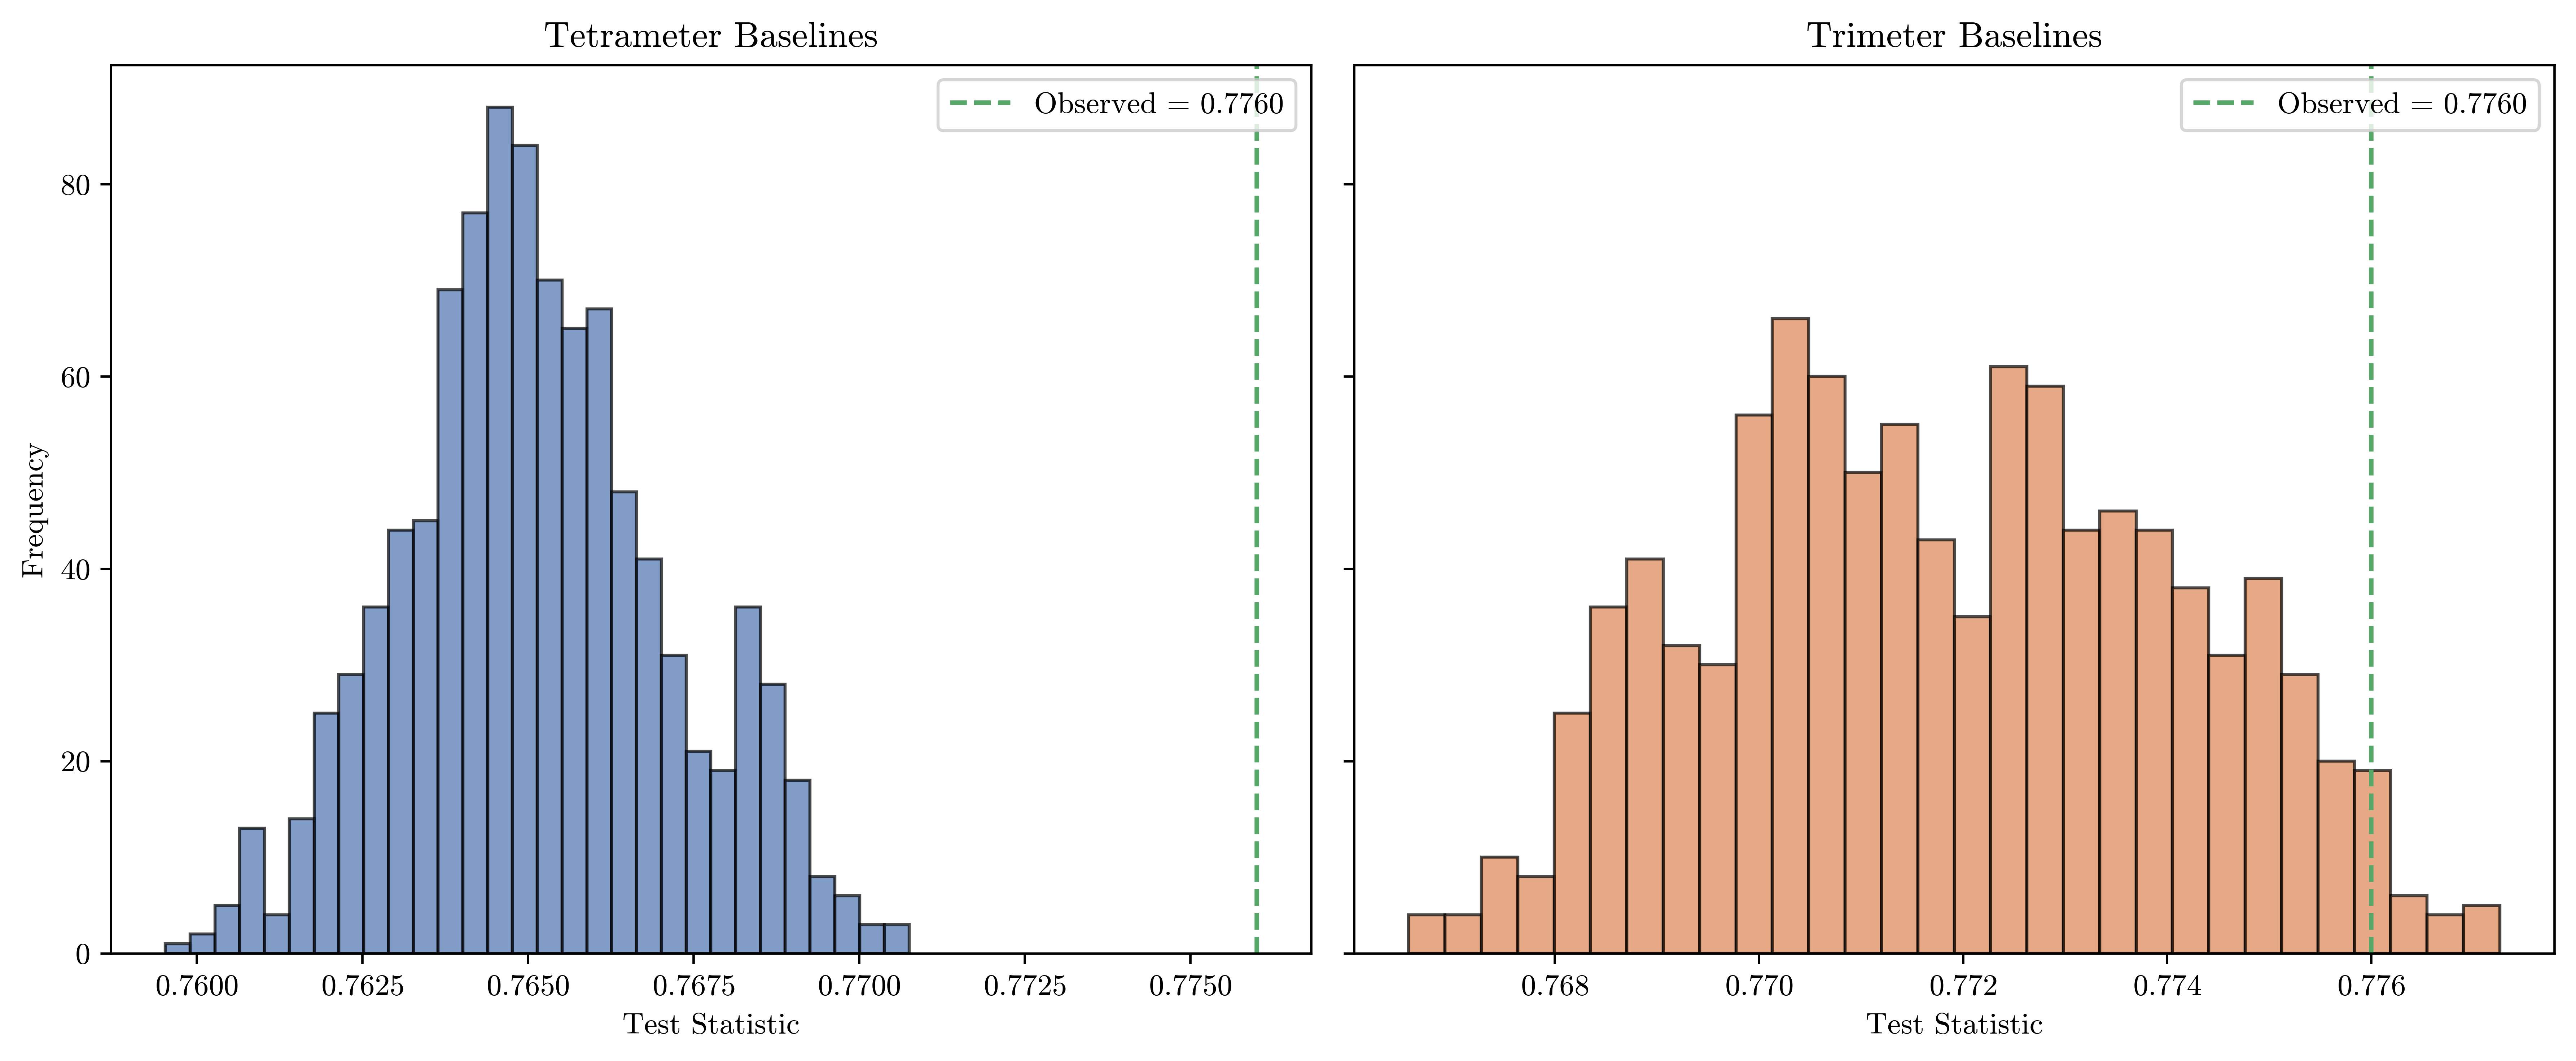

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Convert to float arrays for plotting
T_exp_triads_tetrameter_arr = np.array(T_exp_triads_tetrameter, dtype=float)
T_exp_triads_trimeter_arr = np.array(T_exp_triads_trimeter, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

# Tetrameter distribution
axes[0].hist(T_exp_triads_tetrameter_arr, bins=bins, color=default_colors[0], edgecolor='k', alpha=0.7)
axes[0].axvline(T_obs_triads, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_triads:.4f}')
#axes[0].axvline(np.min(T_exp_triads_tetrameter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_triads_tetrameter_arr):.4f}')
axes[0].set_title('Tetrameter Baselines')
axes[0].set_xlabel('Test Statistic')
axes[0].set_ylabel('Frequency')
axes[0].legend(loc="upper right")

# Trimeter distribution
axes[1].hist(T_exp_triads_trimeter_arr, bins=bins, color=default_colors[1], edgecolor='k', alpha=0.7)
axes[1].axvline(T_obs_triads, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_triads:.4f}')
#axes[1].axvline(np.min(T_exp_triads_trimeter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_triads_trimeter_arr):.4f}')
axes[1].set_title('Trimeter Baselines')
axes[1].set_xlabel('Test Statistic')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(ROOT / "media/permutation_tests/aristophanes_comp_baseline_distributions.png", dpi=600)
plt.show()

# Permutation test 2: Barys

In [12]:
from aristophanis_cantica import barys_oxys_metric_corpus

corpus_dict = barys_oxys_metric_corpus(ROOT / 'data/compiled', exclude_substr='baseline')
T_obs = corpus_dict["barys_metric"]
print("T_obs:", T_obs)

T_obs: 0.43811807012286486


In [13]:
import os
import pickle
import shutil

from aristophanis_cantica import barys_oxys_metric_corpus
from tqdm import tqdm

########################
test_statistics = base_cycles
########################


def pooled_barys_metric_via_temp_corpus(selected_files, pool_dir):
    """Compute barys metric by materializing one 78-file pooled corpus on disk."""
    if pool_dir.exists():
        shutil.rmtree(pool_dir)
    pool_dir.mkdir(parents=True, exist_ok=True)

    for i, src in enumerate(selected_files, start=1):
        dst = pool_dir / f"pool_{i:03d}.xml"
        shutil.copy2(src, dst)

    metric_dict = barys_oxys_metric_corpus(folder=str(pool_dir), exclude_substr=None)
    return float(metric_dict["barys_metric"])

if not from_pickle:
    scratch_root = temp_dir / "_tmp_barys_pool"

    expected_barys_tetrameter = {}
    for n in tqdm(range(1, test_statistics + 1), desc="Tetrameter barys"):
        # 1. Select 78 baseline songs with the target strophicity distribution
        selected = []

        for m in range(n, n + 72):
            selected.append(temp_dir / "tetrameter_2" / f"tetrameter_2_perm_{m:05d}.xml")
        for m in range(n, n + 2):
            selected.append(temp_dir / "tetrameter_3" / f"tetrameter_3_perm_{m:05d}.xml")
        for m in range(n, n + 4):
            selected.append(temp_dir / "tetrameter_4" / f"tetrameter_4_perm_{m:05d}.xml")

        if len(selected) != 78:
            raise ValueError(f"Expected 78 songs in tetrameter pool for n={n}, but got {len(selected)}")

        # 2. Materialize pooled corpus and compute statistic directly
        pool_dir = scratch_root / "tetrameter_pool"
        expected_barys_tetrameter[n] = pooled_barys_metric_via_temp_corpus(selected, pool_dir)

if from_pickle:
    with open(ROOT / "data/cache/perm_comp_barys_tetrameter_stats.pkl", "rb") as f:
        expected_barys_tetrameter = pickle.load(f)

mean_tet = sum(expected_barys_tetrameter.values()) / len(expected_barys_tetrameter)

print("#" * 40)
print("TETRAMETER (BARYS)")
print("#" * 40)
print()
print(f"Mean expected barys metric across {test_statistics} pooled corpora: \033[92m{mean_tet:.4f}\033[0m\n")

Tetrameter barys: 100%|██████████| 1000/1000 [14:21<00:00,  1.16it/s]

########################################
TETRAMETER (BARYS)
########################################

Mean expected barys metric across 1000 pooled corpora: 0.3997



In [14]:
# Pickle and save the results

if not from_pickle:
    png_folder = ROOT / "data/cache"
    png_folder.mkdir(parents=True, exist_ok=True)
    with open(ROOT / "data/cache/perm_barys_tetrameter_stats.pkl", "wb") as f:
        pickle.dump(expected_barys_tetrameter, f)

In [15]:
if not from_pickle:
    expected_barys_trimeter = {}
    for n in tqdm(range(1, test_statistics + 1), desc="Trimeter barys"):
        # 1. Select 78 baseline songs with the target strophicity distribution
        selected = []

        for m in range(n, n + 72):
            selected.append(temp_dir / "trimeter_2" / f"trimeter_2_perm_{m:05d}.xml")
        for m in range(n, n + 2):
            selected.append(temp_dir / "trimeter_3" / f"trimeter_3_perm_{m:05d}.xml")
        for m in range(n, n + 4):
            selected.append(temp_dir / "trimeter_4" / f"trimeter_4_perm_{m:05d}.xml")

        if len(selected) != 78:
            raise ValueError(f"Expected 78 songs in trimeter pool for n={n}, but got {len(selected)}")

        # 2. Materialize pooled corpus and compute statistic directly
        pool_dir = scratch_root / "trimeter_pool"
        expected_barys_trimeter[n] = pooled_barys_metric_via_temp_corpus(selected, pool_dir)

if from_pickle:
    with open(ROOT / "data/cache/perm_comp_barys_trimeter_stats.pkl", "rb") as f:
        expected_barys_trimeter = pickle.load(f)

mean_tri = sum(expected_barys_trimeter.values()) / len(expected_barys_trimeter)

print("#" * 40)
print("TRIMETER (BARYS)")
print("#" * 40)
print()
print(f"Mean expected barys metric across {test_statistics} pooled corpora: \033[92m{mean_tri:.4f}\033[0m\n")

Trimeter barys: 100%|██████████| 1000/1000 [13:04<00:00,  1.27it/s]

########################################
TRIMETER (BARYS)
########################################

Mean expected barys metric across 1000 pooled corpora: 0.3490



In [16]:
# Pickle and save the results

if not from_pickle:
    png_folder = ROOT / "data/cache"
    png_folder.mkdir(parents=True, exist_ok=True)
    with open(ROOT / "data/cache/perm_barys_trimeter_stats.pkl", "wb") as f:
        pickle.dump(expected_barys_trimeter, f)

    # Optional cleanup after all statistics are computed
    if scratch_root.exists():
        shutil.rmtree(scratch_root)

In [17]:
'''
One observed test statistic from Cell 18:
T_obs_barys = corpus_dict["barys_metric"]

Two lists of expected test statistics:
expected_barys_tetrameter,
expected_barys_trimeter

One-sided permutation test (upper tail).
'''

import numpy as np

if "corpus_dict" not in globals() or "barys_metric" not in corpus_dict:
    raise RuntimeError("Run Cell 18 first so corpus_dict['barys_metric'] is available.")

T_obs_barys = float(corpus_dict["barys_metric"])

T_exp_barys_tetrameter = np.asarray(list(expected_barys_tetrameter.values()), dtype=float)
T_exp_barys_trimeter = np.asarray(list(expected_barys_trimeter.values()), dtype=float)


def permutation_p_value(T_obs, baseline_arr):
    ge_count = np.sum(baseline_arr >= T_obs)  # upper-tail, one-sided
    p = (1 + ge_count) / (1 + baseline_arr.size)
    return p, ge_count


p_tetrameter_barys, ge_tetrameter_barys = permutation_p_value(T_obs_barys, T_exp_barys_tetrameter)
p_trimeter_barys, ge_trimeter_barys = permutation_p_value(T_obs_barys, T_exp_barys_trimeter)

print("#" * 40)
print("Barys one-sided permutation test")
print("#" * 40)
print(f"Observed T_obs_barys (from Cell 18) = {T_obs_barys:.6f}\n")

print("Tetrameter baseline")
print(f"  n={T_exp_barys_tetrameter.size}")
print(f"  min={T_exp_barys_tetrameter.min():.6f}  max={T_exp_barys_tetrameter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_tetrameter_barys}")
print(f"  p={p_tetrameter_barys:.30f}\n")

print("Trimeter baseline")
print(f"  n={T_exp_barys_trimeter.size}")
print(f"  min={T_exp_barys_trimeter.min():.6f}  max={T_exp_barys_trimeter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_trimeter_barys}")
print(f"  p={p_trimeter_barys:.30f}\n")

same_sorted_values = np.array_equal(np.sort(T_exp_barys_tetrameter), np.sort(T_exp_barys_trimeter))
print(f"Baselines have identical multiset of values: {same_sorted_values}")

if p_tetrameter_barys == p_trimeter_barys:
    print(
        "Equal p-values here mean equal tail counts for this T_obs; "
        "that is not automatically a bug."
    )

########################################
Barys one-sided permutation test
########################################
Observed T_obs_barys (from Cell 18) = 0.438118

Tetrameter baseline
  n=1000
  min=0.389124  max=0.409787
  ge_count (>= T_obs)=0
  p=0.000999000999000999000132505756

Trimeter baseline
  n=1000
  min=0.335521  max=0.361974
  ge_count (>= T_obs)=0
  p=0.000999000999000999000132505756

Baselines have identical multiset of values: False
Equal p-values here mean equal tail counts for this T_obs; that is not automatically a bug.


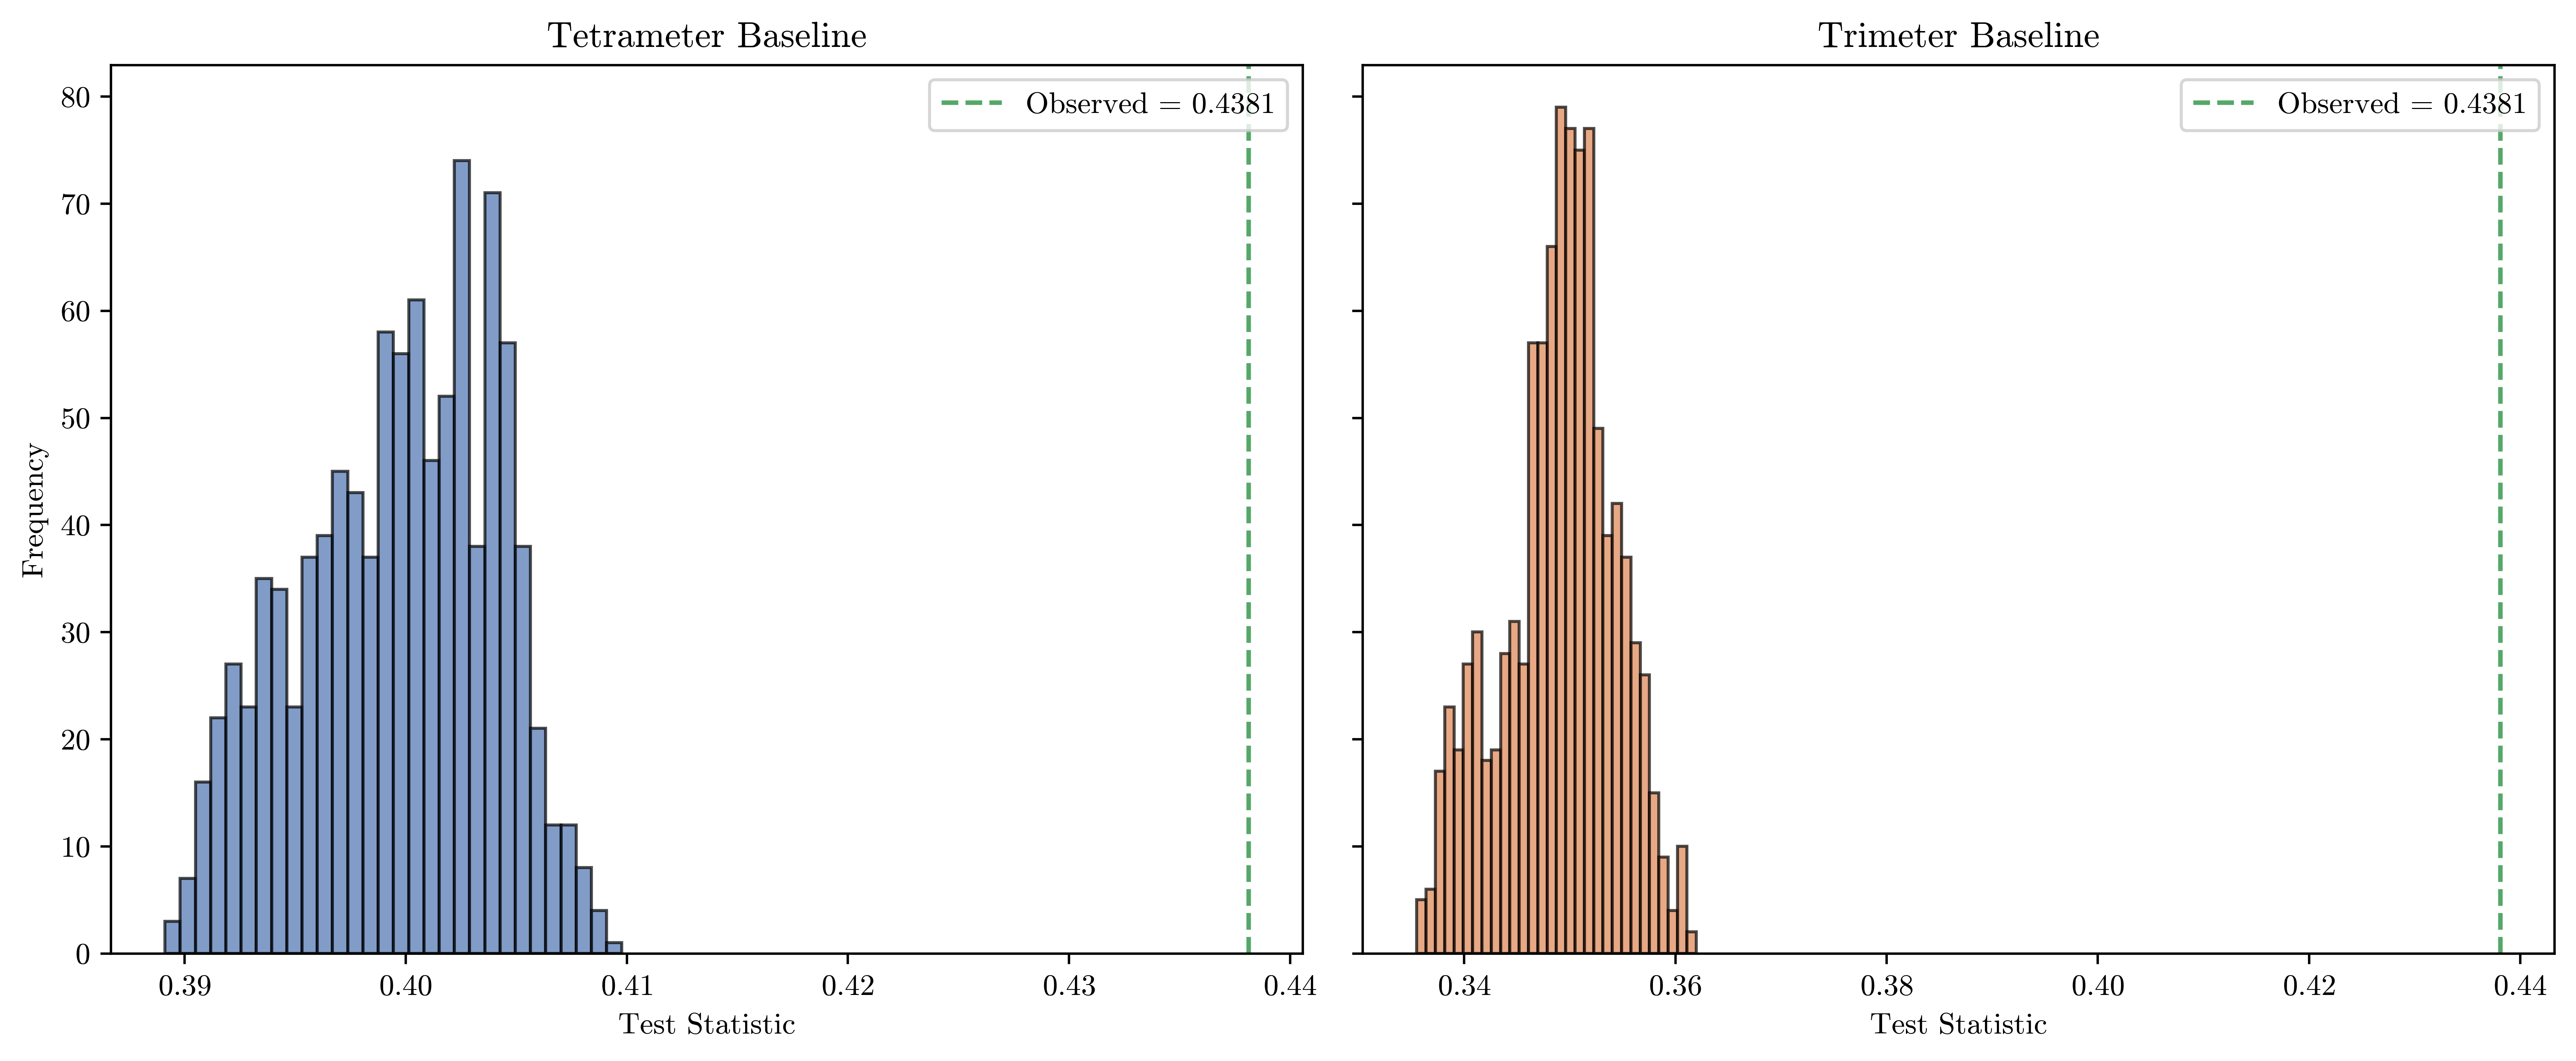

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Convert to float arrays for plotting
T_exp_barys_tetrameter_arr = np.array(T_exp_barys_tetrameter, dtype=float)
T_exp_barys_trimeter_arr = np.array(T_exp_barys_trimeter, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

# Tetrameter distribution
axes[0].hist(T_exp_barys_tetrameter_arr, bins=bins, color=default_colors[0], edgecolor='k', alpha=0.7)
axes[0].axvline(T_obs_barys, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_barys:.4f}')
# axes[0].axvline(np.min(T_exp_barys_tetrameter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_barys_tetrameter_arr):.4f}')
axes[0].set_title('Tetrameter Baseline')
axes[0].set_xlabel('Test Statistic')
axes[0].set_ylabel('Frequency')
axes[0].legend(loc="upper right")

# Trimeter distribution
axes[1].hist(T_exp_barys_trimeter_arr, bins=bins, color=default_colors[1], edgecolor='k', alpha=0.7)
axes[1].axvline(T_obs_barys, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_barys:.4f}')
# axes[1].axvline(np.min(T_exp_barys_trimeter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_barys_trimeter_arr):.4f}')
axes[1].set_title('Trimeter Baseline')
axes[1].set_xlabel('Test Statistic')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(ROOT / "media/permutation_tests/aristophanes_barys_baseline_distributions.png", dpi=600)
plt.show()

# Permutation test 3: Orthographic accents

In [6]:
from aristophanis_cantica import accentual_responsion_metric_corpus

dict_orth = accentual_responsion_metric_corpus(ROOT / 'data/compiled')
T_obs_orth = dict_orth["acute_circumflex"]
print(f'Orthograhic acute and circumflex responsion: {T_obs_orth}')

Orthograhic acute and circumflex responsion: 0.25639315098954857


In [8]:
from pathlib import Path
import shutil

from aristophanis_cantica import accentual_responsion_metric_corpus
from tqdm import tqdm

########################
test_statistics = base_cycles
########################


def pooled_orth_metric_via_temp_corpus(selected_files, pool_dir, metric_key="acute_circumflex"):
    """Compute orthographic metric by materializing one 78-file pooled corpus on disk."""
    if pool_dir.exists():
        shutil.rmtree(pool_dir)
    pool_dir.mkdir(parents=True, exist_ok=True)

    for i, src in enumerate(selected_files, start=1):
        dst = pool_dir / f"pool_{i:03d}.xml"
        shutil.copy2(src, dst)

    metric_dict = accentual_responsion_metric_corpus(str(pool_dir), exclude_substr=None)
    return float(metric_dict[metric_key])


scratch_root = temp_dir / "_tmp_orth_pool"

expected_orth_tetrameter = {}
for n in tqdm(range(1, test_statistics + 1), desc="Tetrameter orth"):
    selected = []

    for m in range(n, n + 72):
        selected.append(temp_dir / "tetrameter_2" / f"tetrameter_2_perm_{m:05d}.xml")
    for m in range(n, n + 2):
        selected.append(temp_dir / "tetrameter_3" / f"tetrameter_3_perm_{m:05d}.xml")
    for m in range(n, n + 4):
        selected.append(temp_dir / "tetrameter_4" / f"tetrameter_4_perm_{m:05d}.xml")

    if len(selected) != 78:
        raise ValueError(f"Expected 78 songs in tetrameter pool for n={n}, but got {len(selected)}")

    pool_dir = scratch_root / "tetrameter_pool"
    expected_orth_tetrameter[n] = pooled_orth_metric_via_temp_corpus(
        selected, pool_dir, metric_key="acute_circumflex"
    )

mean_tet = sum(expected_orth_tetrameter.values()) / len(expected_orth_tetrameter)

print("#" * 40)
print("TETRAMETER (ORTHOGRAPHIC ACUTE+CIRCUMFLEX)")
print("#" * 40)
print()
print(f"Mean expected orthographic metric across {test_statistics} pooled corpora: \033[92m{mean_tet:.4f}\033[0m\n")

Tetrameter orth: 100%|██████████| 1000/1000 [09:50<00:00,  1.69it/s]

########################################
TETRAMETER (ORTHOGRAPHIC ACUTE+CIRCUMFLEX)
########################################

Mean expected orthographic metric across 1000 pooled corpora: 0.2386



In [10]:
import pickle

# Pickle and save the results


png_folder = ROOT / "data/cache"
png_folder.mkdir(parents=True, exist_ok=True)
with open(ROOT / "data/cache/perm_orth_tetrameter_stats.pkl", "wb") as f:
    pickle.dump(expected_orth_tetrameter, f)

In [11]:
expected_orth_trimeter = {}
for n in tqdm(range(1, test_statistics + 1), desc="Trimeter orth"):
    selected = []

    for m in range(n, n + 72):
        selected.append(temp_dir / "trimeter_2" / f"trimeter_2_perm_{m:05d}.xml")
    for m in range(n, n + 2):
        selected.append(temp_dir / "trimeter_3" / f"trimeter_3_perm_{m:05d}.xml")
    for m in range(n, n + 4):
        selected.append(temp_dir / "trimeter_4" / f"trimeter_4_perm_{m:05d}.xml")

    if len(selected) != 78:
        raise ValueError(f"Expected 78 songs in trimeter pool for n={n}, but got {len(selected)}")

    pool_dir = scratch_root / "trimeter_pool"
    expected_orth_trimeter[n] = pooled_orth_metric_via_temp_corpus(
        selected, pool_dir, metric_key="acute_circumflex"
    )

mean_tri = sum(expected_orth_trimeter.values()) / len(expected_orth_trimeter)

print("#" * 40)
print("TRIMETER (ORTHOGRAPHIC ACUTE+CIRCUMFLEX)")
print("#" * 40)
print()
print(f"Mean expected orthographic metric across {test_statistics} pooled corpora: \033[92m{mean_tri:.4f}\033[0m\n")

Trimeter orth: 100%|██████████| 1000/1000 [09:15<00:00,  1.80it/s]

########################################
TRIMETER (ORTHOGRAPHIC ACUTE+CIRCUMFLEX)
########################################

Mean expected orthographic metric across 1000 pooled corpora: 0.1799



In [13]:
# Pickle and save the results

png_folder = ROOT / "data/cache"
png_folder.mkdir(parents=True, exist_ok=True)
with open(ROOT / "data/cache/perm_orth_trimeter_stats.pkl", "wb") as f:
    pickle.dump(expected_orth_trimeter, f)

if scratch_root.exists():
    shutil.rmtree(scratch_root)

In [14]:
'''
One observed test statistic from the orthographic corpus cell:
T_obs_orth

Two lists of expected test statistics:
expected_orth_tetrameter,
expected_orth_trimeter

One-sided permutation test (upper tail).
'''

import numpy as np

if "T_obs_orth" not in globals():
    raise RuntimeError("Run the orthographic observed-stat cell first so T_obs_orth is available.")

T_obs_orth = float(T_obs_orth)

T_exp_orth_tetrameter = np.asarray(list(expected_orth_tetrameter.values()), dtype=float)
T_exp_orth_trimeter = np.asarray(list(expected_orth_trimeter.values()), dtype=float)


def permutation_p_value(T_obs, baseline_arr):
    ge_count = np.sum(baseline_arr >= T_obs)  # upper-tail, one-sided
    p = (1 + ge_count) / (1 + baseline_arr.size)
    return p, ge_count


p_tetrameter_orth, ge_tetrameter_orth = permutation_p_value(T_obs_orth, T_exp_orth_tetrameter)
p_trimeter_orth, ge_trimeter_orth = permutation_p_value(T_obs_orth, T_exp_orth_trimeter)

print("#" * 40)
print("Orthographic acute+circumflex one-sided permutation test")
print("#" * 40)
print(f"Observed T_obs_orth = {T_obs_orth:.6f}\n")

print("Tetrameter baseline")
print(f"  n={T_exp_orth_tetrameter.size}")
print(f"  min={T_exp_orth_tetrameter.min():.6f}  max={T_exp_orth_tetrameter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_tetrameter_orth}")
print(f"  p={p_tetrameter_orth:.30f}\n")

print("Trimeter baseline")
print(f"  n={T_exp_orth_trimeter.size}")
print(f"  min={T_exp_orth_trimeter.min():.6f}  max={T_exp_orth_trimeter.max():.6f}")
print(f"  ge_count (>= T_obs)={ge_trimeter_orth}")
print(f"  p={p_trimeter_orth:.30f}\n")

same_sorted_values = np.array_equal(np.sort(T_exp_orth_tetrameter), np.sort(T_exp_orth_trimeter))
print(f"Baselines have identical multiset of values: {same_sorted_values}")

if p_tetrameter_orth == p_trimeter_orth:
    print(
        "Equal p-values here mean equal tail counts for this T_obs; "
        "that is not automatically a bug."
    )

########################################
Orthographic acute+circumflex one-sided permutation test
########################################
Observed T_obs_orth = 0.256393

Tetrameter baseline
  n=1000
  min=0.230483  max=0.248477
  ge_count (>= T_obs)=0
  p=0.000999000999000999000132505756

Trimeter baseline
  n=1000
  min=0.170804  max=0.191275
  ge_count (>= T_obs)=0
  p=0.000999000999000999000132505756

Baselines have identical multiset of values: False
Equal p-values here mean equal tail counts for this T_obs; that is not automatically a bug.


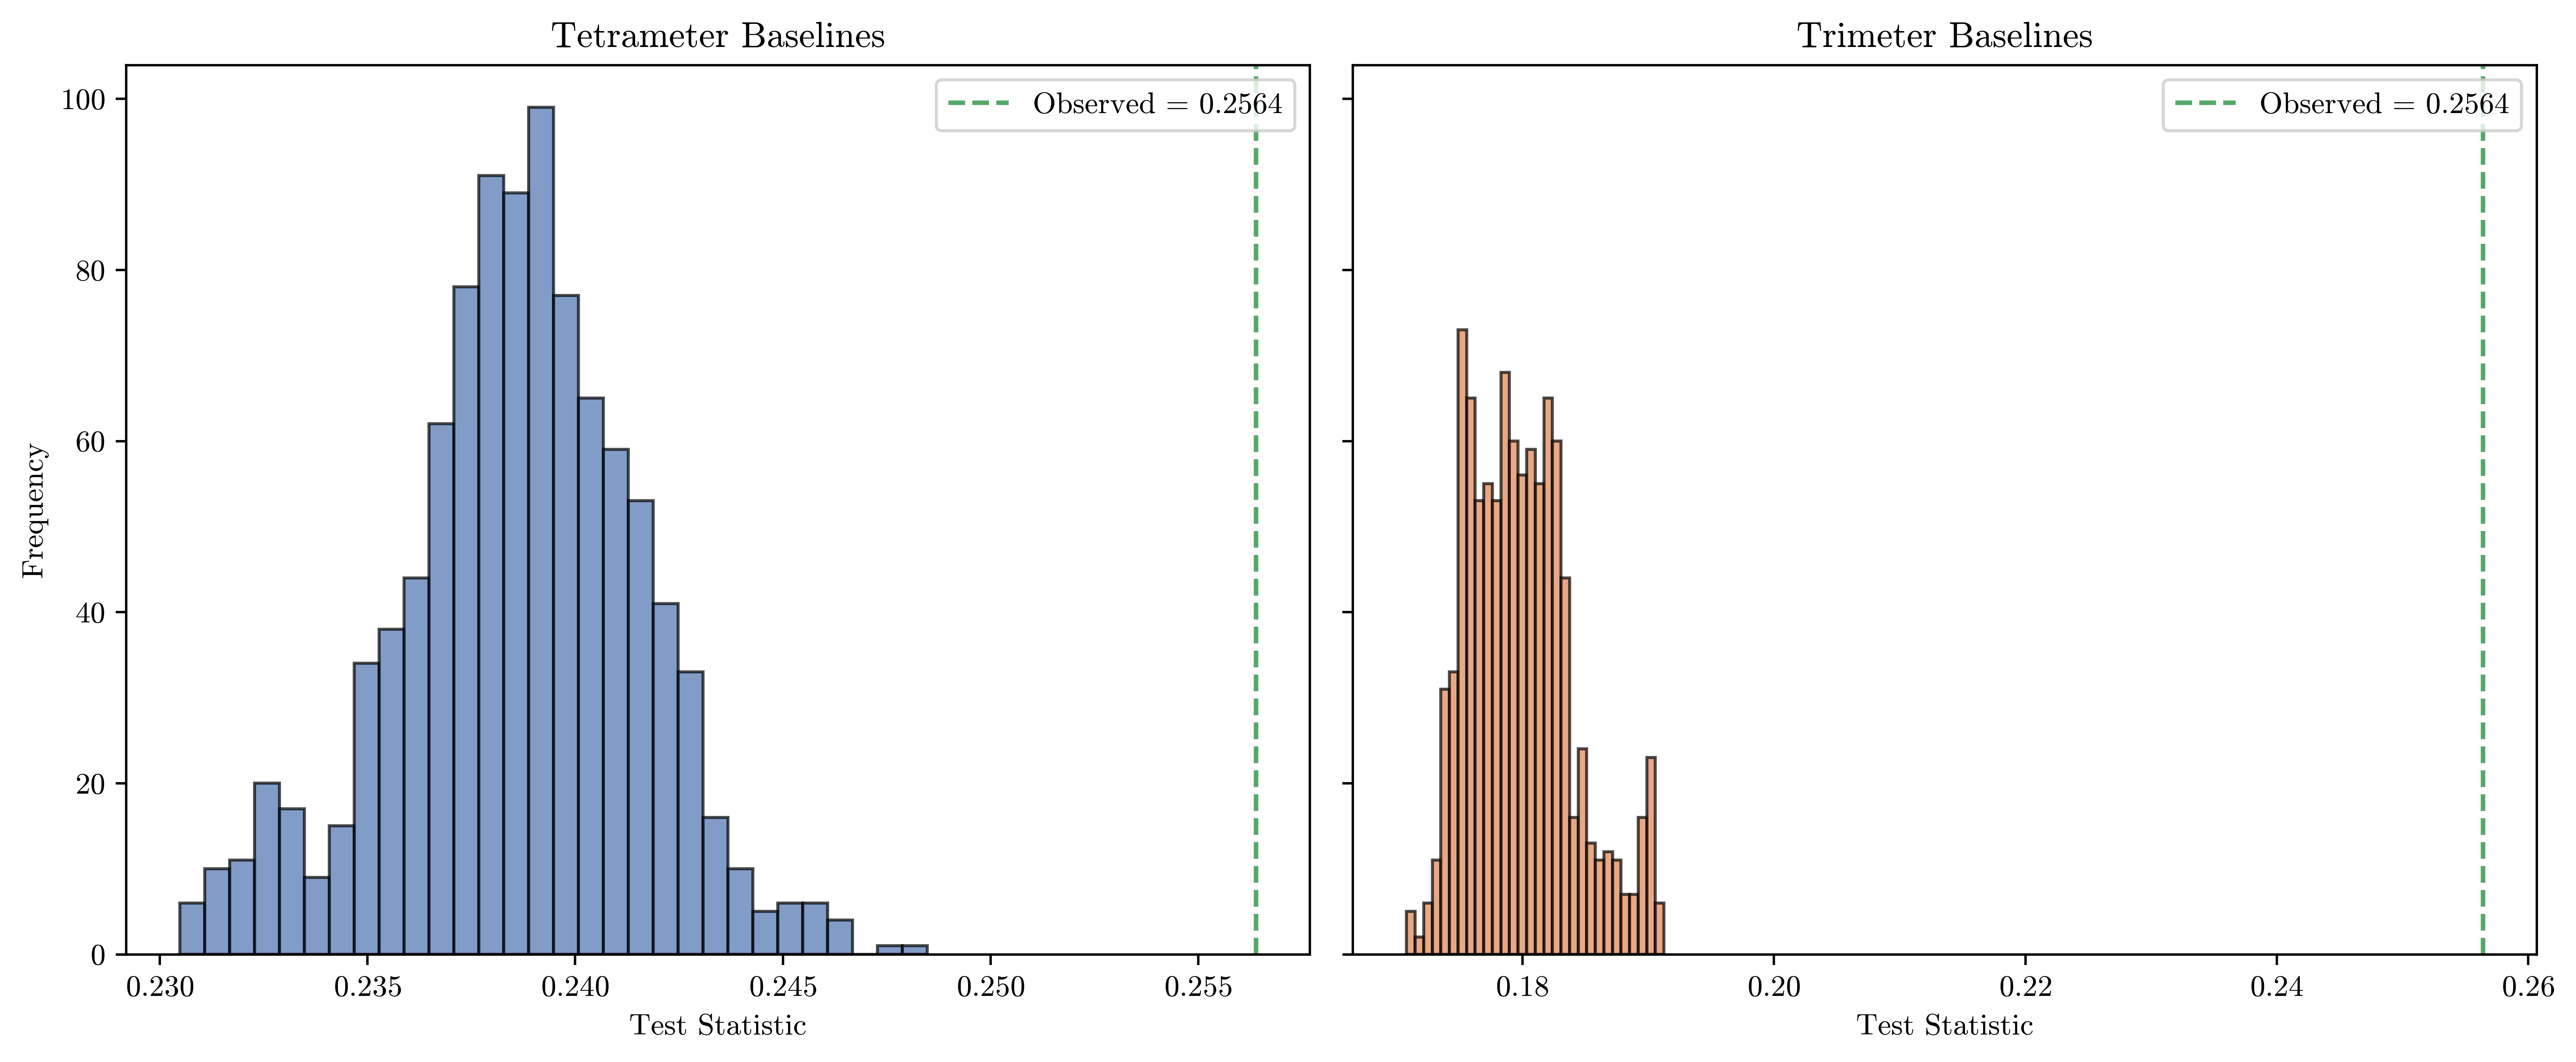

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from aristophanis_cantica.plot import apply_plotting_poetry_palette

apply_plotting_poetry_palette()
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Convert to float arrays for plotting
T_exp_orth_tetrameter_arr = np.array(T_exp_orth_tetrameter, dtype=float)
T_exp_orth_trimeter_arr = np.array(T_exp_orth_trimeter, dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bins = 30

# Tetrameter distribution
axes[0].hist(T_exp_orth_tetrameter_arr, bins=bins, color=default_colors[0], edgecolor='k', alpha=0.7)
axes[0].axvline(T_obs_orth, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_orth:.4f}')
# axes[0].axvline(np.min(T_exp_orth_tetrameter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_orth_tetrameter_arr):.4f}')
axes[0].set_title('Tetrameter Baselines')
axes[0].set_xlabel('Test Statistic')
axes[0].set_ylabel('Frequency')
axes[0].legend(loc="upper right")

# Trimeter distribution
axes[1].hist(T_exp_orth_trimeter_arr, bins=bins, color=default_colors[1], edgecolor='k', alpha=0.7)
axes[1].axvline(T_obs_orth, color=default_colors[2], linestyle='--', label=f'Observed = {T_obs_orth:.4f}')
# axes[1].axvline(np.min(T_exp_orth_trimeter_arr), color='purple', linestyle=':', label=f'Min = {np.min(T_exp_orth_trimeter_arr):.4f}')
axes[1].set_title('Trimeter Baselines')
axes[1].set_xlabel('Test Statistic')
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(ROOT / "media/permutation_tests/aristophanes_orth_baseline_distributions.png", dpi=600)
plt.show()